# 1. Importar csv

In [2]:
import pandas as pd

df_ventas = pd.read_csv('dataset_ventas.csv', encoding='utf-8')
df_direcciones = pd.read_csv('DIRECCIONES.csv', encoding='utf-8')

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_ventas.csv'

# 2. Selección de datos

In [ ]:
df_direcciones_new = df_direcciones.set_index("ID_pedido")
df_ventas_new = df_ventas.drop(columns=["Comercio", "Fecha"])
df_completo = pd.merge(
    df_ventas_new,
    df_direcciones_new[["tipo_entrega", "email"]],
    left_on="ID Pedido",
    right_index=True,
    how="left"
)

# 3. Declaramos ID Pedido como nuevo y único índice

In [ ]:
df_completo.set_index("ID Pedido")

,ID Factura,Ciudad,Tipo cliente,Sexo,Línea de negocio,Precio Unitario,Cantidad,Total,IVA,Pago,tipo_entrega,email
ID Pedido,,,,,,,,,,,,
56904,56904-C1,Vigo,Existente,Mujer,Belleza y perfumer?a,"431,569826004199",42,"18125,9326921764","3806,44586535703",Tarjeta cr?dito,Correos,twana_ellwood@yahoo.com
56904,56904-C2,Pontevedra,Existente,Mujer,Supermercado,"427,753653339589",32,"13688,1169068669","2874,50455044204",Tarjeta cr?dito,Correos,twana_ellwood@yahoo.com
56904,56904-C3,Vigo,Existente,Mujer,Supermercado,"125,119713221405",55,"6881,58422717729","1445,13268770723",Tarjeta cr?dito,Correos,twana_ellwood@yahoo.com
56904,56904-C4,Vigo,Existente,Mujer,Belleza y perfumer?a,"499,885503285254",35,"17495,9926149839","3674,15844914662",Tarjeta cr?dito,Correos,twana_ellwood@yahoo.com
56904,56904-C5,Nigr?n,Existente,Mujer,Cocinas,"216,976405127412",8,"1735,81124101929","364,520360614051",Tarjeta cr?dito,Correos,twana_ellwood@yahoo.com
...,...,...,...,...,...,...,...,...,...,...,...,...
30066,30066-C3,A Coru?a,Existente,Hombre,Otros,"974,516979626758",20,"19490,3395925352","4092,97131443238",Efectivo,Domicilio,cris_watt@hotmail.com
30066,30066-C4,A Coru?a,Existente,Hombre,Otros,"131,572594042298",39,"5131,33116764963","1077,57954520642",Efectivo,Domicilio,cris_watt@hotmail.com
30066,30066-C5,Vigo,Existente,Hombre,Belleza y perfumer?a,"814,358657150635",59,"48047,1607718874","10089,9037620964",Efectivo,Domicilio,cris_watt@hotmail.com


# 4. Tratamiento de datos nulos

In [ ]:
df_completo.isnull().sum() #Hacemos el sumatorio de nulos para ver que columnas tienen nulos y cuando

ID Pedido            0
ID Factura           0
Ciudad               0
Tipo cliente         2
Sexo                 1
Línea de negocio     0
Precio Unitario      1
Cantidad             0
Total                2
IVA                  1
Pago                 0
tipo_entrega         0
email               11
dtype: int64

In [ ]:
#Primero, convertimos el total y precio unitario a float para poder manejarlos
df_completo["Total"] = (
    df_completo["Total"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df_completo["Precio Unitario"] = (
    df_completo["Precio Unitario"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df_completo["Total"] = pd.to_numeric(df_completo["Total"], errors="coerce")
df_completo["Precio Unitario"] = pd.to_numeric(df_completo["Precio Unitario"], errors="coerce")

df_completo["Tipo cliente"] = df_completo["Tipo cliente"].ffill() #Rellenamos los nulos del tipo de cliente con el valor anterior(a falta de otros datos)
df_completo["Sexo"] = df_completo["Sexo"].ffill() #Rellenamos los nulos sexo con el valor anterior(a falta de otros datos)
value = df_completo["Precio Unitario"].mean() 
df_completo["Precio Unitario"] = df_completo["Precio Unitario"].fillna(value) #Rellenamos los nulos de precio unitario con su media
df_completo["Total"] = df_completo["Total"].fillna(
    df_completo["Precio Unitario"] * df_completo["Cantidad"] #Calculamos el total como el precio unitario + la cantidad
)
df_completo["IVA"] = df_completo["IVA"].fillna(
    df_completo["Total"] * 0.21
)
df_completo["email"] = df_completo["email"].fillna("notanemail@gmail.com")

In [ ]:
df_completo.isnull().sum() #Volvemos a hacer el sumatorio de nulos para ver que hemos logrado modificar todos los nulos que existían en el dataframe

ID Pedido           0
ID Factura          0
Ciudad              0
Tipo cliente        0
Sexo                0
Línea de negocio    0
Precio Unitario     0
Cantidad            0
Total               0
IVA                 0
Pago                0
tipo_entrega        0
email               0
dtype: int64

# 5.Tratamiento de datos duplicados

In [ ]:
df_completo.duplicated().sum() #Comprobamos las filas duplicadas que hay en el dataframe

15

In [ ]:
df_completo.drop_duplicates(inplace=True) #Eliminamos todas las filas duplicadas

In [ ]:
df_completo.duplicated().sum() #Corroboramos que en efecto ya no haya filas duplicadas

0

# 6.Preparar datos categóricos

In [ ]:
dummies_ciudad = pd.get_dummies(df_completo['Ciudad'], prefix='city')
df_completo = pd.concat([df_completo, dummies_ciudad], axis=1)
df_completo['Tipo cliente'] = df_completo['Tipo cliente'].map({'Existente':1, 'Nuevo': 0})
df_completo['Sexo'] = df_completo['Sexo'].map({'Hombre':1, 'Mujer': 0})
dummies_negocio = pd.get_dummies(df_completo['Línea de negocio'], prefix='marketline')
df_completo = pd.concat([df_completo, dummies_negocio], axis=1)
dummies_payment = pd.get_dummies(df_completo['Pago'], prefix='payment')
df_completo = pd.concat([df_completo, dummies_payment], axis=1)
dummies_shipping = pd.get_dummies(df_completo['tipo_entrega'], prefix='shipping')
df_completo = pd.concat([df_completo, dummies_shipping], axis=1)
display(df_completo)

## He usado one hot encoder para los datos categóricos multiclase ya que es bastante efectivo y no genera demasiadas columnas, y para los datos categóricos binarios usé la codificación binaria ya que es la apropiada para estos casos

# 7.Gráficos

<Axes: title={'center': 'Pedidos por sexo'}, ylabel='count'>

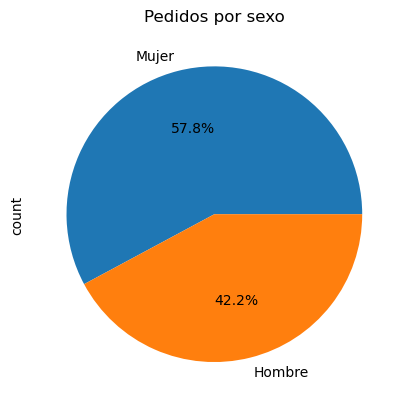

In [ ]:
df_completo['Sexo'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Pedidos por sexo'
)

## En este gráfico vemos el porcentaje de pedidos por sexo, y llegamos a la conclusión de que las mujeres hacen más pedidos que los hombres, aunque por poca diferencia

<Axes: title={'center': 'Pedidos a líneas de negocios por ciudad'}, xlabel='Ciudad', ylabel='Línea de negocio'>

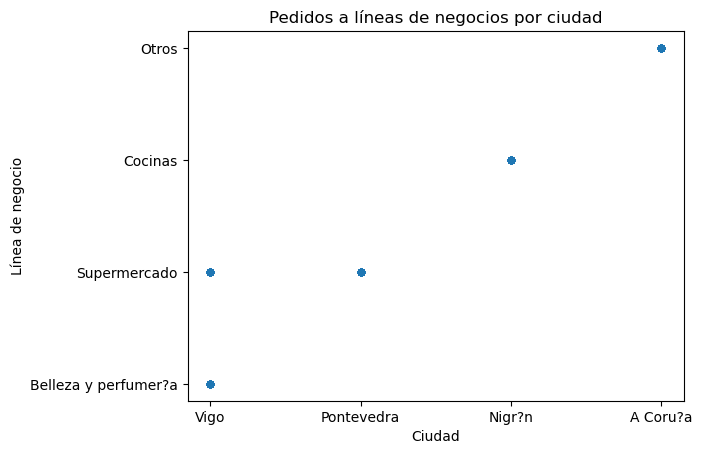

In [ ]:
df_completo.plot(
    kind='scatter',
    x='Ciudad',
    y='Línea de negocio',
    title='Pedidos a líneas de negocios por ciudad'
)

## En este gráfico vemos los pedidos a líneas de negocio por ciudad. Es particularmente interesante ver que todas las ciudades menos vigo solo se limitan a una línea de negocios

<Axes: title={'center': 'Cantidad por línea de negocio'}, xlabel='Línea de negocio'>

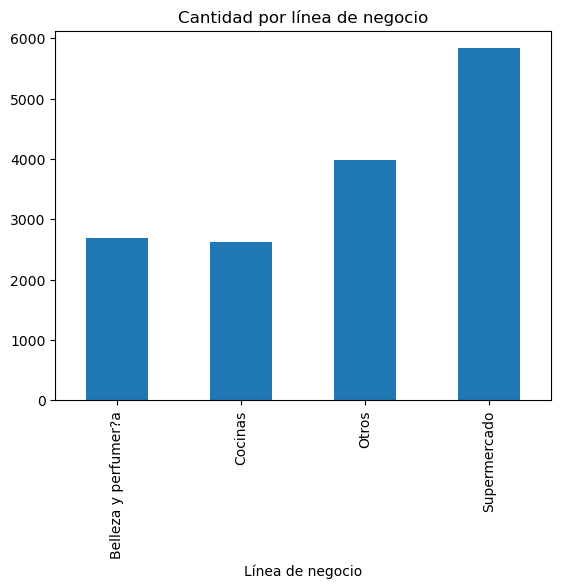

In [ ]:
df_completo.groupby("Línea de negocio")["Cantidad"].sum().plot(
    kind='bar',
    x='Línea de negocio',
    y='Cantidad',
    title='Cantidad por línea de negocio'
)

## En este gráfico vemos la cantidad por cada línea de negocio. Me pareció interesante ver estos dos datos relacionados, ya que así se ve en que línea de negocio se pide más cantidad

<Axes: title={'center': 'Total por ciudad'}, xlabel='Ciudad'>

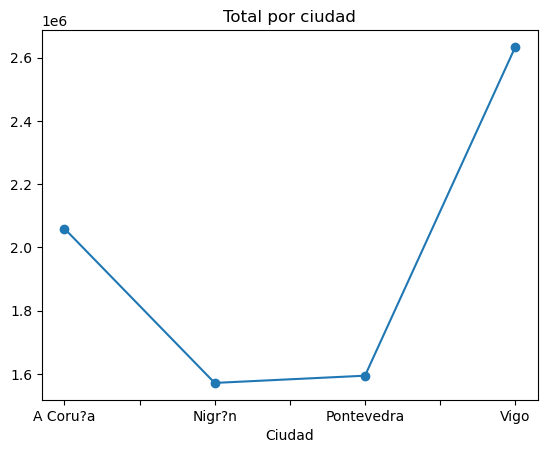

In [ ]:
df_completo.groupby("Ciudad")["Total"].sum().plot(
    kind='line',
    marker='o',
    title='Total por ciudad'
)

## En este gráfico, vemos los gastos totales de los pedidos por ciudad, siendo la que más gasta Vigo, por mucha diferencia

<Axes: >

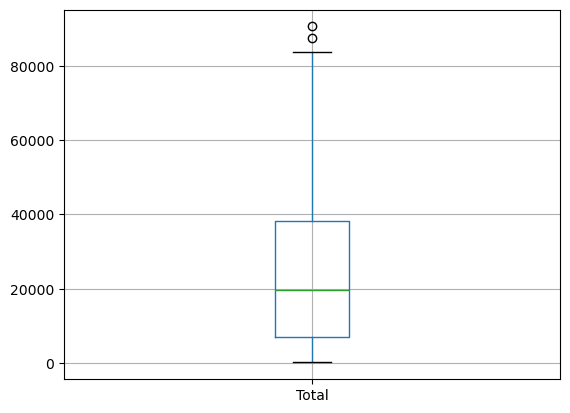

In [ ]:
df_completo.boxplot(column='Total')


## En esta gráfica podemos ver las estadísticas del total de todos los pedidos, además de sus outliers